<a href="https://colab.research.google.com/github/Shreyapowar9961/Deep_Learning_sem6/blob/main/LAB8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Experiment No. 08

Name : Shreya Nandkumar Powar

Class : TYDS-65

PRN : 2324001231

Github Repo :

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications import ResNet50

from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D

from tensorflow.keras.models import Model

import matplotlib.pyplot as plt

import numpy as np

import cv2
import os
import random

In [ ]:
dataset_path = "/content/drive/MyDrive/kidney_cancer_dataset"

In [ ]:
print(os.listdir(dataset_path))

['Test_images', 'Training_images']


In [ ]:
train_path = dataset_path + "/Training_images"

test_path = dataset_path + "/Test_images"

In [ ]:
print(os.listdir(train_path))

['Grade4', 'Grade1', 'Grade3', 'Grade0', 'Grade2']


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [ ]:
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 171 images belonging to 5 classes.
Found 106 images belonging to 5 classes.


In [ ]:
def build_model(base_model):

    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output

    x = GlobalAveragePooling2D()(x)

    x = Dense(128,
              activation='relu')(x)

    x = Dropout(0.5)(x)

    predictions = Dense(5,
                        activation='softmax')(x)

    model = Model(
        inputs=base_model.input,
        outputs=predictions
    )

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
vgg16_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

vgg16_model = build_model(vgg16_base)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
history_vgg16 = vgg16_model.fit(
    train_data,
    validation_data=test_data,
    epochs=5
)

Epoch 1/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 219s 38s/step - accuracy: 0.1637 - loss: 1.8632 - val_accuracy: 0.1981 - val_loss: 1.5996
Epoch 2/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 193s 34s/step - accuracy: 0.3158 - loss: 1.5576 - val_accuracy: 0.2547 - val_loss: 1.5515
Epoch 3/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 188s 31s/step - accuracy: 0.3509 - loss: 1.4150 - val_accuracy: 0.2547 - val_loss: 1.4701
Epoch 4/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 180s 31s/step - accuracy: 0.5439 - loss: 1.2425 - val_accuracy: 0.2547 - val_loss: 1.4402
Epoch 5/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 193s 34s/step - accuracy: 0.6433 - loss: 1.1248 - val_accuracy: 0.2925 - val_loss: 1.4051


In [ ]:
vgg19_base = VGG19(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

vgg19_model = build_model(vgg19_base)

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
history_vgg19 = vgg19_model.fit(
    train_data,
    validation_data=test_data,
    epochs=5
)

Epoch 1/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 229s 40s/step - accuracy: 0.2398 - loss: 1.8275 - val_accuracy: 0.1887 - val_loss: 1.6344
Epoch 2/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 225s 39s/step - accuracy: 0.2807 - loss: 1.6543 - val_accuracy: 0.3585 - val_loss: 1.6357
Epoch 3/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 225s 39s/step - accuracy: 0.2982 - loss: 1.5151 - val_accuracy: 0.3396 - val_loss: 1.5387
Epoch 4/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 281s 51s/step - accuracy: 0.4620 - loss: 1.3640 - val_accuracy: 0.3962 - val_loss: 1.4676
Epoch 5/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 224s 39s/step - accuracy: 0.4912 - loss: 1.3098 - val_accuracy: 0.2642 - val_loss: 1.4717


In [ ]:
resnet_base = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

resnet_model = build_model(resnet_base)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
history_resnet = resnet_model.fit(
    train_data,
    validation_data=test_data,
    epochs=5
)

Epoch 1/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 74s 11s/step - accuracy: 0.2222 - loss: 1.9237 - val_accuracy: 0.2453 - val_loss: 1.6411
Epoch 2/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 80s 15s/step - accuracy: 0.2982 - loss: 1.6758 - val_accuracy: 0.4340 - val_loss: 1.5710
Epoch 3/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 61s 12s/step - accuracy: 0.2339 - loss: 1.6241 - val_accuracy: 0.3396 - val_loss: 1.5574
Epoch 4/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 82s 10s/step - accuracy: 0.3275 - loss: 1.5345 - val_accuracy: 0.4340 - val_loss: 1.5507
Epoch 5/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 61s 11s/step - accuracy: 0.3567 - loss: 1.4879 - val_accuracy: 0.4340 - val_loss: 1.5238


In [ ]:
vgg16_loss, vgg16_acc = vgg16_model.evaluate(test_data)

vgg19_loss, vgg19_acc = vgg19_model.evaluate(test_data)

resnet_loss, resnet_acc = resnet_model.evaluate(test_data)

print("VGG16 Accuracy:", vgg16_acc)

print("VGG19 Accuracy:", vgg19_acc)

print("ResNet50 Accuracy:", resnet_acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 70s 16s/step - accuracy: 0.2925 - loss: 1.4051
4/4 ━━━━━━━━━━━━━━━━━━━━ 85s 19s/step - accuracy: 0.2642 - loss: 1.4717
4/4 ━━━━━━━━━━━━━━━━━━━━ 21s 5s/step - accuracy: 0.4340 - loss: 1.5238
VGG16 Accuracy: 0.2924528419971466
VGG19 Accuracy: 0.2641509473323822
ResNet50 Accuracy: 0.43396225571632385


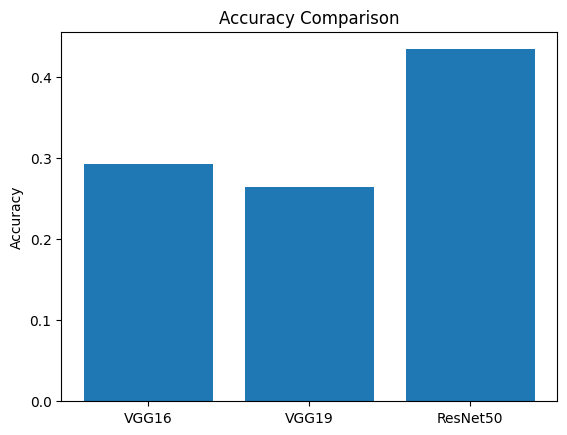

In [ ]:
models = ['VGG16', 'VGG19', 'ResNet50']

accuracies = [
    vgg16_acc,
    vgg19_acc,
    resnet_acc
]

plt.bar(models, accuracies)

plt.title("Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

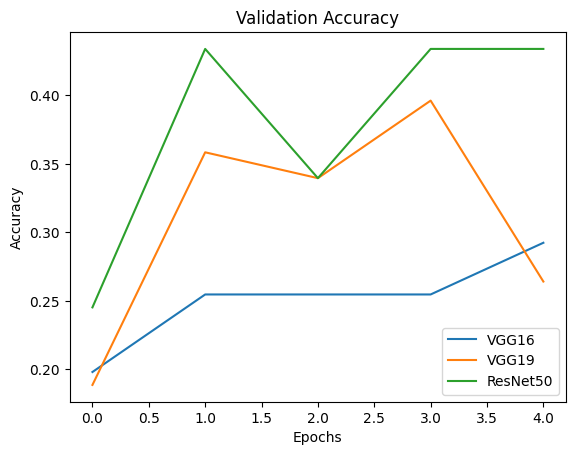

In [ ]:
plt.plot(history_vgg16.history['val_accuracy'],
         label='VGG16')

plt.plot(history_vgg19.history['val_accuracy'],
         label='VGG19')

plt.plot(history_resnet.history['val_accuracy'],
         label='ResNet50')

plt.legend()

plt.title("Validation Accuracy")

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.show()

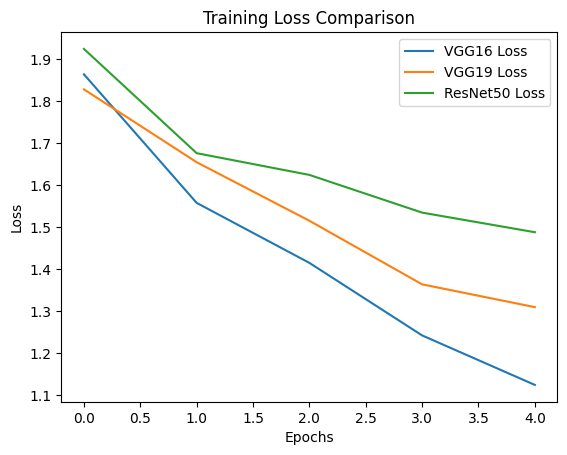

In [ ]:
plt.plot(history_vgg16.history['loss'],
         label='VGG16 Loss')

plt.plot(history_vgg19.history['loss'],
         label='VGG19 Loss')

plt.plot(history_resnet.history['loss'],
         label='ResNet50 Loss')

plt.legend()

plt.title("Training Loss Comparison")

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


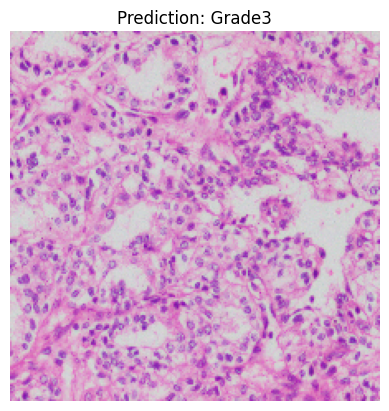

Predicted Result: Grade3


In [ ]:
classes = ['Grade0',
           'Grade1',
           'Grade2',
           'Grade3',
           'Grade4']

random_class = random.choice(classes)

folder_path = f"{test_path}/{random_class}"

random_image = random.choice(
    os.listdir(folder_path)
)

image_path = f"{folder_path}/{random_image}"

img = cv2.imread(image_path)

img_resized = cv2.resize(img, (224,224))

img_normalized = img_resized / 255.0

img_input = np.expand_dims(
    img_normalized,
    axis=0
)

prediction = resnet_model.predict(img_input)

predicted_class = classes[
    np.argmax(prediction)
]

plt.imshow(
    cv2.cvtColor(img_resized,
                 cv2.COLOR_BGR2RGB)
)

plt.title(f"Prediction: {predicted_class}")

plt.axis('off')

plt.show()

print("Predicted Result:", predicted_class)